In [1]:
# General Imports
import datetime
import logging
# Math Imports
import pandas
import seaborn as sns
import torch
import lightning
# Local imports
from cocodeel.dataset import CovarDataset
from cocodeel.model import NeuralNetwork
from cocodeel.model import CovarNeuralNetwork

In [2]:
DEVICE = "cpu"
#torch.set_default_device(DEVICE)
torch.set_default_dtype(torch.float)
torch.manual_seed(0)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [3]:
# Data generation.
def simulate_data(N=3000, q=256, p=1, bz = 1, confounding = True):
    # Random covariates.
    Z = torch.randn(N, p)
    Z = torch.cat((torch.ones(N, 1), Z), 1)
    # Confounded random network inputs.
    delZ = torch.zeros(p, q)
    if confounding:
        delZ[:, q//2:] = torch.ones(p, q//2) / (p**.5 * q**.5)
    X = Z[:,1:] @ delZ + torch.randn(N, q)
    # Output. (No effect of X! This makes evaluation easy, as any learned X effect is from Z!)
    fz = Z[:,1:] @ (bz * torch.ones(p) / p**.5)
    y = fz + torch.randn(N)
    return X, Z, y

def create_dataloaders(X, Z, y, batch_size=256):
    N = len(y)
    # Create training, validation and test data.
    train_data = CovarDataset(X[:N // 3], Z[:N // 3], y[:N // 3])
    val_data = CovarDataset(X[N // 3:2 * N // 3], Z[N // 3:2 * N // 3], y[N // 3:2 * N // 3])
    test_data = CovarDataset(X[2 * N // 3:], Z[2 * N // 3:], y[2 * N // 3:])
    # Create dataloaders.
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [4]:
# Model Backbones.
class IdentityBackbone(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.model = torch.nn.Identity()
    def forward(self, x):
        return self.model(x)

class ShallowBackbone(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.model = torch.nn.Sequential(
            torch.nn.Linear(in_features, out_features),
            torch.nn.ReLU()
        )
    def forward(self, x):
        return self.model(x)

class DeepBackbone(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(in_features, 2 * in_features),
            torch.nn.ReLU(),
            torch.nn.Linear(2 * in_features, 2 * out_features),
            torch.nn.ReLU(),
            torch.nn.Linear(2 * out_features, 2 * out_features),
            torch.nn.ReLU(),
            torch.nn.Linear(2 * out_features, out_features),
            torch.nn.ReLU(),
            torch.nn.Linear(out_features, out_features),
            torch.nn.ReLU()
        )
    def forward(self, x):
        return self.model(x)


In [5]:
def estimate_models(train_loader, val_loader, params):
    # Estimate Baseline Neural Network
    net = NeuralNetwork(**params).to(DEVICE)
    model_checkpoint = lightning.pytorch.callbacks.ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min")
    early_stop_callback = lightning.pytorch.callbacks.EarlyStopping(monitor="val_loss", patience=64, mode="min")
    trainer = lightning.Trainer(max_epochs=1000, enable_progress_bar=False, callbacks=[model_checkpoint, early_stop_callback])
    trainer.fit(net, train_loader, val_loader)
    net = NeuralNetwork.load_from_checkpoint(model_checkpoint.best_model_path).to(DEVICE)

    # Estimate Baseline Neural Network with Covariates
    net_covar = CovarNeuralNetwork(**params).to(DEVICE)
    model_checkpoint = lightning.pytorch.callbacks.ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min")
    early_stop_callback = lightning.pytorch.callbacks.EarlyStopping(monitor="val_loss", patience=64, mode="min")
    trainer = lightning.Trainer(max_epochs=1000, enable_progress_bar=False, callbacks=[model_checkpoint, early_stop_callback])
    trainer.fit(net_covar, train_loader, val_loader)
    net_covar = CovarNeuralNetwork.load_from_checkpoint(model_checkpoint.best_model_path).to(DEVICE)

    return {"NN": net, "Covar NN": net_covar}

def get_predictions(model, loader):
    model.eval()
    yhat, fxhat, fzhat = [], [], []
    for idx, batch in enumerate(loader):
        with torch.no_grad():
            yhat.append(model.predict_step(batch, idx).squeeze())
            fxhat.append(model.predict_deep(batch, idx).squeeze())
            fzhat.append(model.predict_deep(batch, idx).squeeze())
    return torch.cat(yhat), torch.cat(fxhat), torch.cat(fzhat)

def mse_decomposition(rhat):
    return {"mse": torch.mean(rhat**2).numpy(), "rmse": torch.sqrt(torch.mean(rhat**2)).numpy(),
            "bias": torch.mean(rhat).numpy(), "variance": torch.var(rhat).numpy()}


In [6]:
N, q, p, bz = 7500, 32, 1, 0
# Simulate data
X, Z, y = simulate_data(N=N, q=q, p=p, bz=bz, confounding=False)
train_loader, val_loader, test_loader = create_dataloaders(X, Z, y, batch_size=256)

# Model Parameters
params = {
    "backbone": IdentityBackbone,
    "output_func": torch.nn.Identity,
    "loss_func": torch.nn.MSELoss,
    "optimizer": torch.optim.AdamW,
    "num_covars": p+1,
    "num_features": q,
    "backbone_params": {"in_features": q, "out_features": q},
    "optimizer_params": {"lr": 0.1, "weight_decay": 0.0001},
    "scheduler": torch.optim.lr_scheduler.StepLR,
    "scheduler_params": {"step_size": 16, "gamma": 0.5}
}

In [7]:
models = estimate_models(train_loader, val_loader, params)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Manuel Pfeuffer\anaconda3\envs\dc-mri\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
Missing logger folder: C:\Promotion\Software\cocodeel\notebooks\paper\Fig1 Concurvity\lightning_logs

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | backbone       | IdentityBackbone | 0      | train
1 | deep_predictor | Linear           | 33     | train
2 | output_f

In [8]:
print("Baseline NN")
yhat, fxhat, fzhat = get_predictions(models["NN"], test_loader)
print(mse_decomposition(fxhat)['rmse'])
print("Covariate NN")
yhat, fxhat, fzhat = get_predictions(models["Covar NN"], test_loader)
print(mse_decomposition(fxhat)['rmse'])

Baseline NN
0.14147152
Covariate NN
0.14813907


In [9]:
# Simulation run over nsim iterations for different values of q
N, q, p = 30000, 32, 1
nsim = 3
results = []
for conf in [False, True]:
    for bz in [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]:
        if bz not in [0, 2.5, 5]: continue
        for backbone in [IdentityBackbone, ShallowBackbone, DeepBackbone]:
            params_q = params.copy()
            params_q["backbone"] = backbone
            params_q["num_covars"] = p+1
            params_q["num_features"] = q
            params_q["backbone_params"]["in_features"] = q
            params_q["backbone_params"]["out_features"] = q
            for i in range(nsim):
                X, Z, y = simulate_data(N=N, q=q, p=p, bz=bz, confounding=conf)
                train_loader, val_loader, test_loader = create_dataloaders(X, Z, y, batch_size=256)
                models = estimate_models(train_loader, val_loader, params_q)
                for key, model in models.items():
                    yhat, fxhat, fzhat = get_predictions(model, test_loader)
                    rmse_bias = mse_decomposition(fxhat)['rmse']
                    results.append({"confounding": conf, "bz": bz, "backbone": type(model.backbone).__name__,
                                    "model": key, "run": i, "rmse": rmse_bias})
results_df = pandas.DataFrame.from_records(results)
results_df.to_csv(f"results/results_ovb_nsim={nsim}_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}.csv")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name           | Type             | Params | Mode 
------------------------------------------------------------
0 | backbone       | IdentityBackbone | 0      | train
1 | deep_predictor | Linear           | 33     | train
2 | output_func    | Identity         | 0      | train
3 | loss_func      | MSELoss          | 0      | train
------------------------------------------------------------
33        Trainable params
0         Non-trainable params
33        Total params
0.000     Total estimated model params size (MB)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | backbone         | IdentityBackbone | 0      | train
1 | deep_predictor   | Linear           | 32     | train
2 | struct_pred

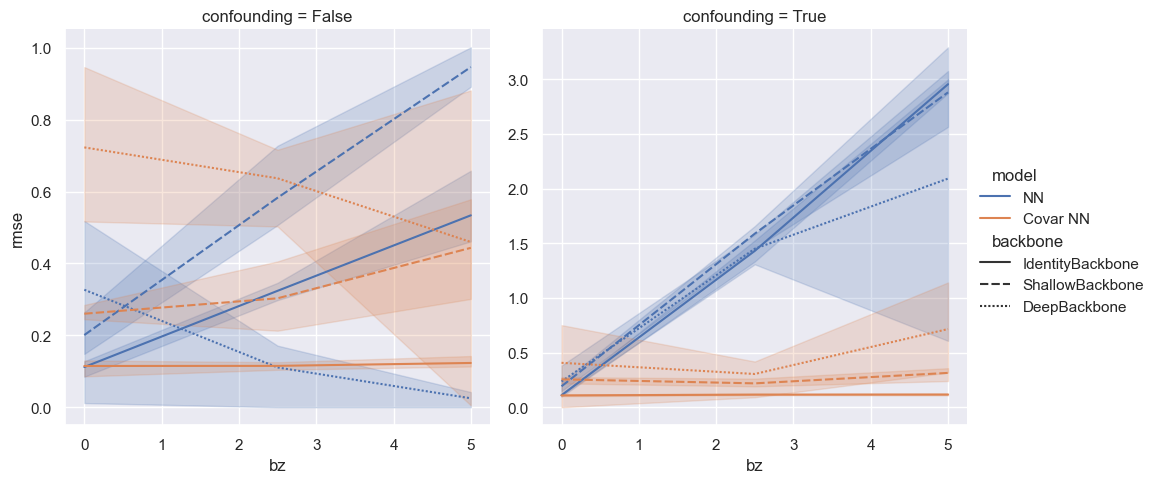

In [10]:
sns.set_theme()

df = results_df.copy()
df['backbone'] = df['backbone'].astype(str)
df['model'] = df['model'].astype(str)
df['bz'] = df['bz'].astype(float)
df['rmse'] = df['rmse'].astype(float)

sns.relplot(data=df, kind="line",
             x="bz", y="rmse", col="confounding",
            hue="model", style="backbone",
            facet_kws={"sharey": False})

pandas.core.frame.DataFrame